In [50]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [51]:
df = pd.read_csv('stud.csv')

In [52]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [53]:
X = df.drop(['math_score'], axis=1)
y = df['math_score']
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [54]:
num_features = X.select_dtypes(exclude='object').columns
categorical_features = X.select_dtypes(include='str').columns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('num',num_transformer, num_features),
        ('cat',categorical_transformer, categorical_features)
    ])


In [55]:
X_transformed = preprocessor.fit_transform(X)
X_transformed.shape

(1000, 19)

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 19), (200, 19), (800,), (200,))

In [57]:
def evaluate_model(model,X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    return r2, mae, mse, rmse

In [58]:
models = {
    'LinearRegression':LinearRegression(),
    'Ridge':Ridge(),
    'Lasso':Lasso(),    
    'K-Neighbors':KNeighborsRegressor(),
    'DecisionTreeRegressor':DecisionTreeRegressor(),
    'randomForestRegressor':RandomForestRegressor(),
    'xgboost':XGBRegressor(),
    'catboot':CatBoostRegressor(verbose=False),
    'AdaBoostRegressor':AdaBoostRegressor()
}

model_list = []
r2_score_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model_fit = model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    r2,mae,mse,rmse = evaluate_model(model, X_train, y_train, X_test, y_test)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print(f"R2 Score: {r2}")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")

    print('----------------------------------')
    r2_score_list.append(r2)

LinearRegression
R2 Score: 0.8804332983749565
MAE: 4.214763142474849
MSE: 29.095169866715466
RMSE: 5.3939938697328405
----------------------------------
Ridge
R2 Score: 0.880593148502874
MAE: 4.211100688014259
MSE: 29.05627219234827
RMSE: 5.3903870169356365
----------------------------------
Lasso
R2 Score: 0.8253200795629732
MAE: 5.157879138921815
MSE: 42.506332351273414
RMSE: 6.519688056285624
----------------------------------
K-Neighbors
R2 Score: 0.7837702557426202
MAE: 5.619
MSE: 52.617
RMSE: 7.253757646902741
----------------------------------
DecisionTreeRegressor
R2 Score: 0.7324302288500295
MAE: 6.37
MSE: 65.11
RMSE: 8.069076774947677
----------------------------------
randomForestRegressor
R2 Score: 0.8504195507104966
MAE: 4.670433333333333
MSE: 36.39866720138889
RMSE: 6.033130795978892
----------------------------------
xgboost
R2 Score: 0.8212205171585083
MAE: 5.1036295890808105
MSE: 43.50392150878906
RMSE: 6.595750261250729
----------------------------------
catboot
R2 Sc

In [59]:
pd.DataFrame(list(zip(model_list, r2_score_list)), columns=['Model', 'R2_Score']).sort_values(by='R2_Score', ascending=False)

,Model,R2_Score
1,Ridge,0.880593
0,LinearRegression,0.880433
7,catboot,0.851632
5,randomForestRegressor,0.850420
8,AdaBoostRegressor,0.849715
2,Lasso,0.825320
6,xgboost,0.821221
3,K-Neighbors,0.783770
4,DecisionTreeRegressor,0.732430


In [60]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


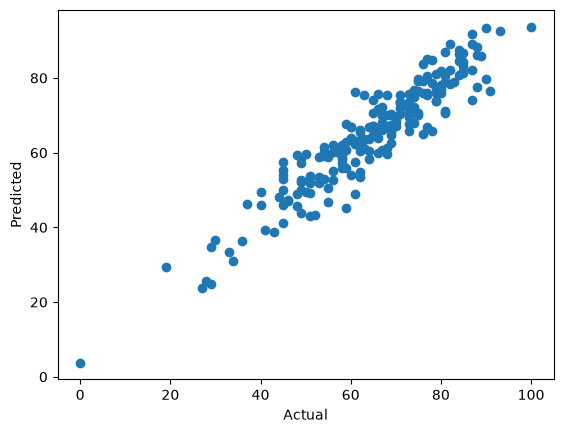

In [61]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

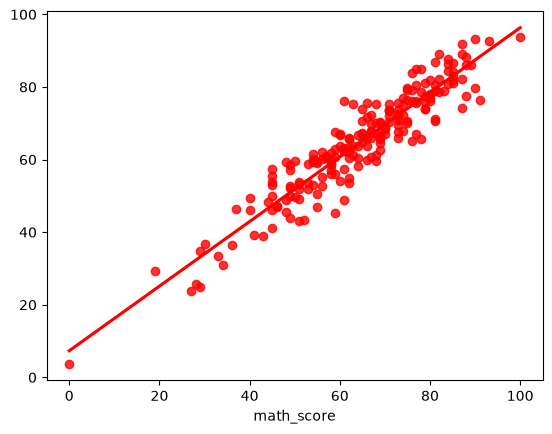

In [62]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [63]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
